# MA-INF 2213 Computer Vision SS26 — Exercise Sheet 03
## Fine-Grained Visual Classification on CUB-200-2011 (25 classes)

**Submission deadline:** 10.06.2026  
**Groups of two** — include a `README.txt` with your names.

# 1. Importing Libraries

In [1]:
import os
import numpy as np
import torch
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import random

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA version    : {torch.version.cuda}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device          : {device}')

PyTorch version : 2.11.0+cu128
CUDA version    : 12.8
Device          : cuda


# 2. Global Settings
## ⚠️ Please DO NOT change this cell

In [2]:
def START_seed():
    seed = 66
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

NUM_CLASSES = 25
MAX_PARAMS  = 500_000
EPOCHS      = 50
IMG_SIZE    = 128   # all images are resized to IMG_SIZE x IMG_SIZE

START_seed()

# 3. Dataset

## 3.1 Dataset Class
## ⚠️ Please DO NOT change this cell

The data you received is organised as follows:
```
data/
└── train_imgs/
    ├── 001.Black_footed_Albatross/
    ├── 002.Laysan_Albatross/
    └── ...  (25 class folders, 001–025)
```

- Only `train_imgs/` is provided. The dataset class splits it into **train** and **validation** sets automatically.
- The **test set** is held out by the instructors.

⚠️ **Do NOT include the dataset in your submission.**


In [9]:
class CUB25Dataset(Dataset):
    """
    Loads the 25-class CUB subset from train_imgs/.

    Args:
        root         : path to the data directory (must contain train_imgs/)
        split        : 'train' | 'val'
                       Both are carved from train_imgs/ using a fixed seed.
        transform    : torchvision transform pipeline
        val_fraction : fraction of train_imgs/ reserved for validation (default 0.2)
    """

    def __init__(self, root, split='train', transform=None, val_fraction=0.2):
        super().__init__()
        assert split in ('train', 'val'), f"split must be 'train' or 'val', got '{split}'"
        self.transform = transform

        img_dir = os.path.join(root, 'train_imgs')

        # Discover classes: sorted folder names -> label 0..24
        class_names = sorted([
            d for d in os.listdir(img_dir)
            if os.path.isdir(os.path.join(img_dir, d))
        ])
        # Keep only the first 25 classes (001–025)
        class_names = class_names[:NUM_CLASSES]
        assert len(class_names) == NUM_CLASSES, (
            f'Expected {NUM_CLASSES} class folders, found {len(class_names)}.'
        )
        self.class_to_idx = {name: idx for idx, name in enumerate(class_names)}

        # Collect all (image_path, label) pairs
        all_samples = []
        for cls_name in class_names:
            cls_dir = os.path.join(img_dir, cls_name)
            label   = self.class_to_idx[cls_name]
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_samples.append((os.path.join(cls_dir, fname), label))

        # Reproducible stratified train/val split
        rng = np.random.RandomState(66)
        train_samples, val_samples = [], []
        for cls_name in class_names:
            cls_samples = [s for s in all_samples if s[1] == self.class_to_idx[cls_name]]
            cls_samples = sorted(cls_samples)  # deterministic order
            idx = np.arange(len(cls_samples))
            rng.shuffle(idx)
            n_val = max(1, int(len(cls_samples) * val_fraction))
            val_samples   += [cls_samples[i] for i in idx[:n_val]]
            train_samples += [cls_samples[i] for i in idx[n_val:]]

        self.samples = train_samples if split == 'train' else val_samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


print('CUB25Dataset defined.')


CUB25Dataset defined.


In [10]:
#!unzip "/content/data.zip" -d "/content/"

## 3.2 Base Transforms and Data Loaders
## ⚠️ Please DO NOT change this cell (used for Tasks 0–4)

In [11]:
# ── Set this to your local data directory ────────────────────────────────────
DATA_ROOT = './data'   # must contain train_imgs/
# ─────────────────────────────────────────────────────────────────────────────

START_seed()


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

base_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

base_val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_batch_size = 64
val_batch_size   = 64


NUM_WORKERS = 0

train_set = CUB25Dataset(DATA_ROOT, split='train', transform=base_train_transform)
val_set   = CUB25Dataset(DATA_ROOT, split='val',   transform=base_val_transform)

train_loader = DataLoader(train_set, batch_size=train_batch_size, shuffle=True,
                          num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_set,   batch_size=val_batch_size,   shuffle=False,
                          num_workers=NUM_WORKERS)

print(f'Train samples : {len(train_set)}')
print(f'Val   samples : {len(val_set)}')
print(f'Classes       : {NUM_CLASSES}')


Train samples : 567
Val   samples : 130
Classes       : 25


## 3.3 Visualising the Data

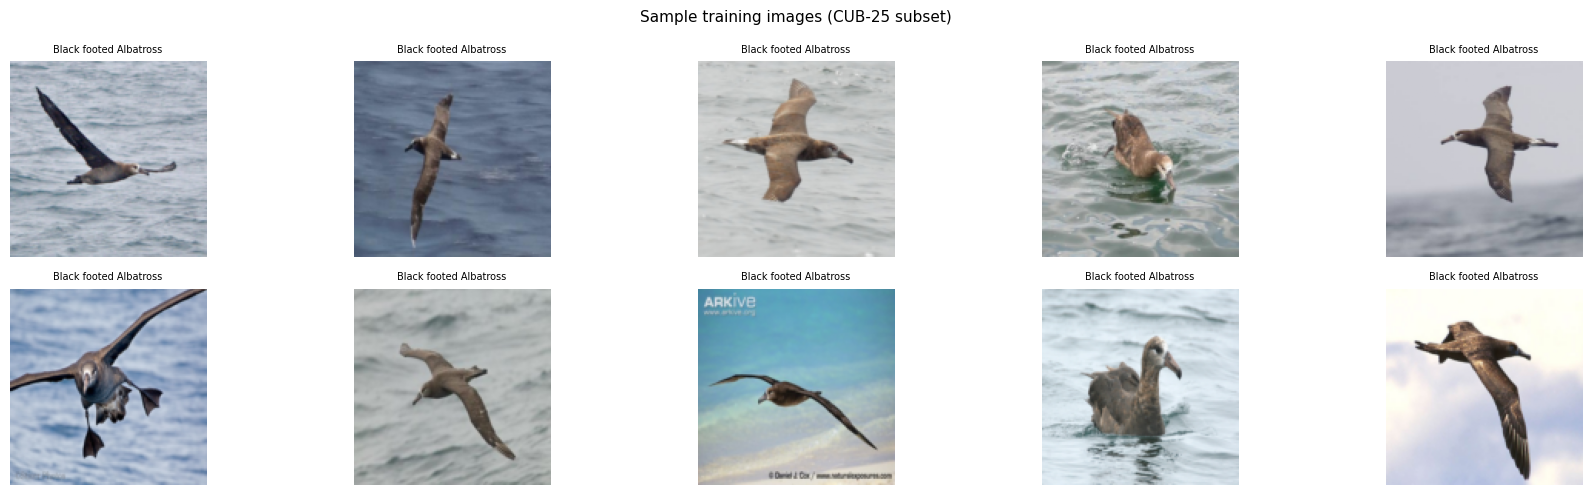

In [12]:
idx_to_class = {v: k for k, v in train_set.class_to_idx.items()}

def denorm(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

plt.figure(figsize=(18, 5))
for i in range(10):
    img, lbl = train_set[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(denorm(img).permute(1, 2, 0).numpy())
    plt.title(idx_to_class[lbl].split('.')[1].replace('_', ' '), fontsize=7)
    plt.axis('off')
plt.suptitle('Sample training images (CUB-25 subset)', fontsize=11)
plt.tight_layout()
plt.show()

# 4. Training & Evaluation Helpers
## ⚠️ Please DO NOT change this cell

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def train_one_epoch(model, device, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0.0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    print(f'  [Train] Epoch {epoch:02d}  Loss: {avg_loss:.4f}')
    return avg_loss


def evaluate(model, device, loader, criterion, split_name='Val'):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            total_loss += criterion(output, target).item()
            correct    += output.argmax(dim=1).eq(target).sum().item()
    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / len(loader.dataset)
    print(f'  [{split_name}]   Loss: {avg_loss:.4f}  Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.2f}%)')
    return accuracy


def run_experiment(model, train_loader, val_loader,
                   lr=1e-3, optimizer_name='Adam', epochs=EPOCHS, device=device):
    """Train model and return (best_val_acc, train_losses, val_accs)."""
    criterion = nn.CrossEntropyLoss()
    if optimizer_name.upper() == 'ADAM':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    model.to(device)
    train_losses, val_accs = [], []
    best_acc, best_epoch = 0.0, 0

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        loss = train_one_epoch(model, device, train_loader, optimizer, criterion, epoch)
        acc  = evaluate(model, device, val_loader, criterion)
        train_losses.append(loss)
        val_accs.append(acc)
        if acc > best_acc:
            best_acc, best_epoch = acc, epoch

    print(f'\nBest val accuracy : {best_acc:.2f}% at epoch {best_epoch}')
    print(f'Total time        : {time.time() - t0:.1f}s')
    print(f'Parameters        : {count_parameters(model):,}')
    return best_acc, train_losses, val_accs


def plot_curves(results_dict, title='Training curves'):
    """results_dict: {label: (train_losses, val_accs)}"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for label, (losses, accs) in results_dict.items():
        ax1.plot(losses, label=label)
        ax2.plot(accs,   label=label)
    ax1.set_title('Train Loss');      ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.set_title('Val Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


print('Helpers defined.')

Helpers defined.


# 5. Task 0 — Baseline Architecture
## ⚠️ Please run the following cells without modification

This is the **base LeNet-style network** adapted for CUB-25 (input `128×128`, 25 output classes).  
All Tasks 1–4 modify this baseline independently — do **not** carry changes between tasks.

In [ ]:
class LeNetBase(nn.Module):
    """
    Baseline network for CUB-25.
    Input : (B, 3, 128, 128)
    Flow  : Conv(3->32,  k=3) -> BN -> ReLU -> MaxPool(2)   # 128->126->63
            Conv(32->64, k=3) -> BN -> ReLU -> MaxPool(2)   #  63-> 61->30
            Conv(64->128,k=3) -> BN -> ReLU -> MaxPool(2)   #  30-> 28->14
            AdaptiveAvgPool(4x4)                             #  14->  4
            Flatten -> FC(128*4*4->128) -> ReLU
                    -> FC(128->64)       -> ReLU
                    -> FC(64->25)
    Parameters: ~368k
    """
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.bn3   = nn.BatchNorm2d(f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [ ]:
START_seed()
baseline = LeNetBase()
print(baseline)
print(f'\nParameters: {count_parameters(baseline):,}')

LeNetBase(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=25, bias=True)
)

Parameters: 365,849


In [ ]:
START_seed()
baseline = LeNetBase()
best_acc_baseline, losses_baseline, accs_baseline = run_experiment(
    baseline, train_loader, val_loader, lr=1e-3, optimizer_name='Adam'
)

  [Train] Epoch 01  Loss: 3.2009
  [Val]   Loss: 3.2057  Accuracy: 9/130 (6.92%)
  [Train] Epoch 02  Loss: 3.0421
  [Val]   Loss: 3.0684  Accuracy: 9/130 (6.92%)
  [Train] Epoch 03  Loss: 2.8591
  [Val]   Loss: 2.9503  Accuracy: 19/130 (14.62%)
  [Train] Epoch 04  Loss: 2.7008
  [Val]   Loss: 2.8607  Accuracy: 17/130 (13.08%)
  [Train] Epoch 05  Loss: 2.5667
  [Val]   Loss: 3.0984  Accuracy: 20/130 (15.38%)
  [Train] Epoch 06  Loss: 2.4114
  [Val]   Loss: 2.9126  Accuracy: 25/130 (19.23%)
  [Train] Epoch 07  Loss: 2.3096
  [Val]   Loss: 3.3147  Accuracy: 23/130 (17.69%)
  [Train] Epoch 08  Loss: 2.2270
  [Val]   Loss: 2.9109  Accuracy: 28/130 (21.54%)
  [Train] Epoch 09  Loss: 2.0350
  [Val]   Loss: 2.8754  Accuracy: 30/130 (23.08%)
  [Train] Epoch 10  Loss: 1.9393
  [Val]   Loss: 2.6831  Accuracy: 32/130 (24.62%)
  [Train] Epoch 11  Loss: 1.8063
  [Val]   Loss: 2.6530  Accuracy: 33/130 (25.38%)
  [Train] Epoch 12  Loss: 1.6625
  [Val]   Loss: 2.5893  Accuracy: 38/130 (29.23%)
  [Train

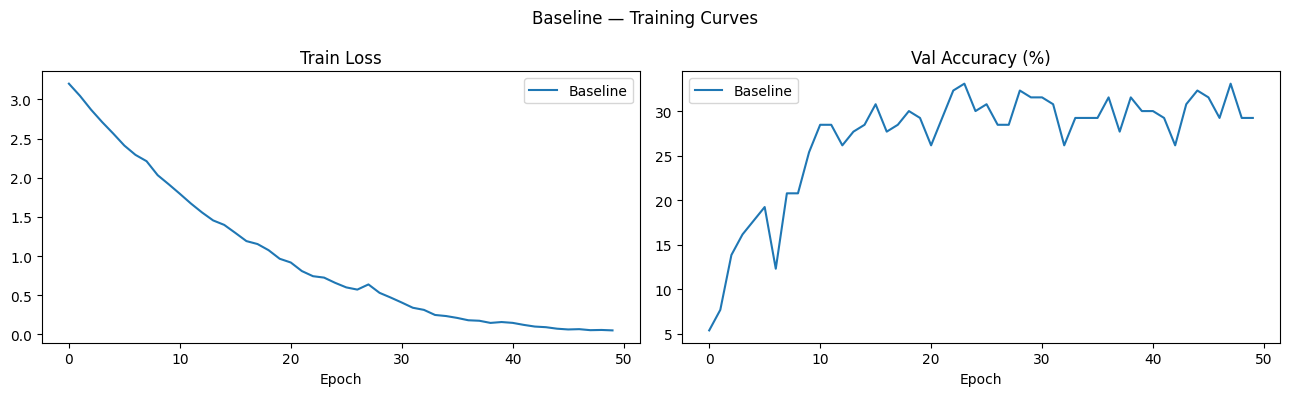

In [ ]:
plot_curves(
    {'Baseline': (losses_baseline, accs_baseline)},
    title='Baseline — Training Curves',
)

---
# Task 1 — Pooling Strategies  *(3 points)*

Modify the base network by (a) replacing MaxPool with AvgPool and (b) using strided convolutions instead of pooling.

For each variant, **implement only the `forward` method** — `__init__` is already filled in.
Report accuracy, parameter count, and training time for both variants and the baseline in your report.

## 1a — Average Pooling

In [ ]:
class LeNet_AvgPool(nn.Module):
    """Task 1a: MaxPool replaced with AvgPool."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.bn3   = nn.BatchNorm2d(f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        # YOUR CODE HERE
        # Same as baseline but replace F.max_pool2d with F.avg_pool2d
        # raise NotImplementedError
        x = F.avg_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.avg_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.avg_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [ ]:
START_seed()
model_avg = LeNet_AvgPool()
best_acc_avg, losses_avg, accs_avg = run_experiment(model_avg, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.1811
  [Val]   Loss: 3.1908  Accuracy: 9/130 (6.92%)
  [Train] Epoch 02  Loss: 2.9853
  [Val]   Loss: 3.0512  Accuracy: 16/130 (12.31%)
  [Train] Epoch 03  Loss: 2.7826
  [Val]   Loss: 3.0502  Accuracy: 21/130 (16.15%)
  [Train] Epoch 04  Loss: 2.5983
  [Val]   Loss: 2.8992  Accuracy: 19/130 (14.62%)
  [Train] Epoch 05  Loss: 2.4833
  [Val]   Loss: 3.3167  Accuracy: 16/130 (12.31%)
  [Train] Epoch 06  Loss: 2.2858
  [Val]   Loss: 2.7928  Accuracy: 22/130 (16.92%)
  [Train] Epoch 07  Loss: 2.1713
  [Val]   Loss: 3.1106  Accuracy: 26/130 (20.00%)
  [Train] Epoch 08  Loss: 2.0381
  [Val]   Loss: 2.7750  Accuracy: 26/130 (20.00%)
  [Train] Epoch 09  Loss: 1.8968
  [Val]   Loss: 2.8187  Accuracy: 28/130 (21.54%)
  [Train] Epoch 10  Loss: 1.8206
  [Val]   Loss: 2.7703  Accuracy: 30/130 (23.08%)
  [Train] Epoch 11  Loss: 1.6721
  [Val]   Loss: 2.5211  Accuracy: 37/130 (28.46%)
  [Train] Epoch 12  Loss: 1.5388
  [Val]   Loss: 2.5641  Accuracy: 31/130 (23.85%)
  [Tra

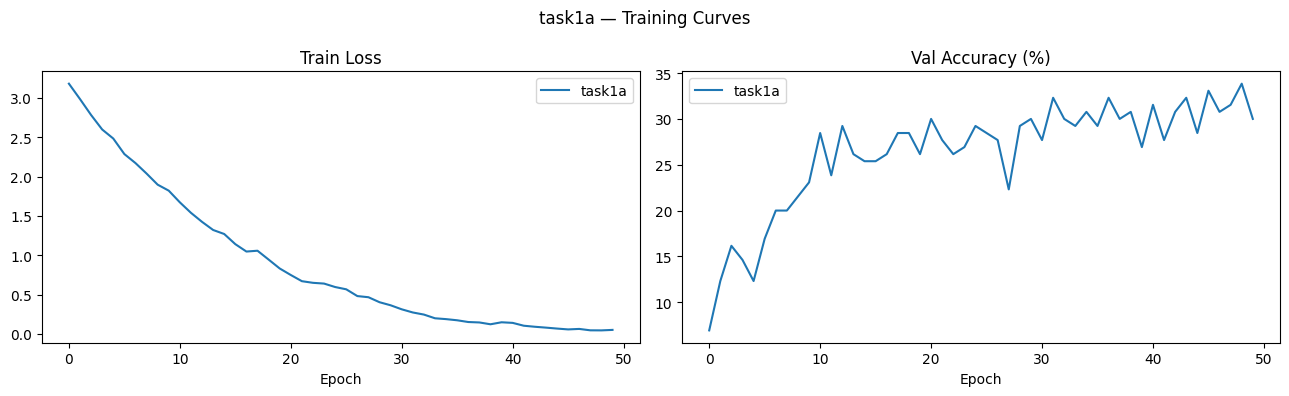

In [ ]:
plot_curves(
    {'task1a': (losses_avg, accs_avg)},
    title='task1a — Training Curves',
)

## 1b — Strided Convolutions
Remove all pooling layers. Use `stride=2` in each `Conv2d` to downsample spatially.
`__init__` is filled in — implement `forward` only.

In [ ]:
class LeNet_Strided(nn.Module):
    """Task 1b: Strided convolutions instead of pooling."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3, stride=2)
        self.bn1   = nn.BatchNorm2d(f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3, stride=2)
        self.bn2   = nn.BatchNorm2d(f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3, stride=2)
        self.bn3   = nn.BatchNorm2d(f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
        # YOUR CODE HERE
        # No pooling — conv with stride=2 handles downsampling
        # Pattern: bn -> relu (x3), then self.pool, flatten, FC
        # raise NotImplementedError


In [ ]:
START_seed()
model_strided = LeNet_Strided()
best_acc_strided, losses_strided, accs_strided = run_experiment(model_strided, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.1824
  [Val]   Loss: 3.1704  Accuracy: 10/130 (7.69%)
  [Train] Epoch 02  Loss: 3.0097
  [Val]   Loss: 3.0815  Accuracy: 13/130 (10.00%)
  [Train] Epoch 03  Loss: 2.8000
  [Val]   Loss: 3.0455  Accuracy: 23/130 (17.69%)
  [Train] Epoch 04  Loss: 2.6325
  [Val]   Loss: 2.8842  Accuracy: 19/130 (14.62%)
  [Train] Epoch 05  Loss: 2.5277
  [Val]   Loss: 3.3703  Accuracy: 23/130 (17.69%)
  [Train] Epoch 06  Loss: 2.3448
  [Val]   Loss: 2.8501  Accuracy: 24/130 (18.46%)
  [Train] Epoch 07  Loss: 2.2239
  [Val]   Loss: 3.2154  Accuracy: 27/130 (20.77%)
  [Train] Epoch 08  Loss: 2.1051
  [Val]   Loss: 2.9504  Accuracy: 29/130 (22.31%)
  [Train] Epoch 09  Loss: 1.9446
  [Val]   Loss: 2.6900  Accuracy: 31/130 (23.85%)
  [Train] Epoch 10  Loss: 1.8724
  [Val]   Loss: 2.9527  Accuracy: 31/130 (23.85%)
  [Train] Epoch 11  Loss: 1.7460
  [Val]   Loss: 2.5440  Accuracy: 32/130 (24.62%)
  [Train] Epoch 12  Loss: 1.6106
  [Val]   Loss: 2.7780  Accuracy: 31/130 (23.85%)
  [Tr

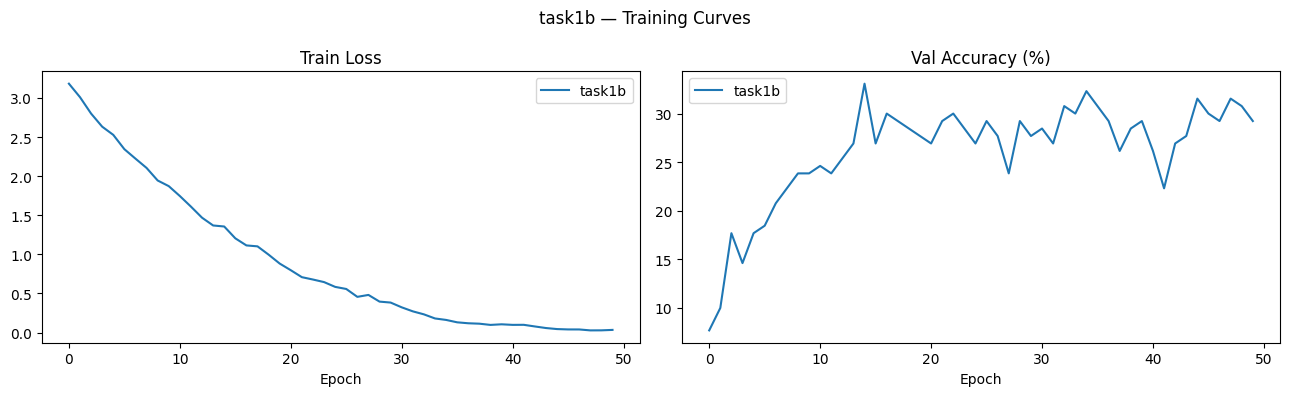

In [ ]:
plot_curves(
    {'task1b': (losses_strided, accs_strided)},
    title='task1b — Training Curves',
)

---
# Task 2 — Activation Function Comparison  *(2 points)*

Replace **all** ReLU activations with the specified alternative.
`__init__` is filled in — implement `forward` only.

## 2a — Leaky ReLU  (α = 0.1)

In [ ]:
class LeNet_LeakyReLU(nn.Module):
    """Task 2a: All ReLU replaced with Leaky ReLU (negative_slope=0.1)."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.bn3   = nn.BatchNorm2d(f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.1), 2)
        x = F.max_pool2d(F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.1), 2)
        x = F.max_pool2d(F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.1), 2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.leaky_relu(self.fc1(x), negative_slope=0.1)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.1)
        return self.fc3(x)
        # YOUR CODE HERE
        # Replace F.relu with F.leaky_relu(x, negative_slope=0.1)
        # raise NotImplementedError


In [ ]:
START_seed()
model_lrelu = LeNet_LeakyReLU()
best_acc_lrelu, losses_lrelu, accs_lrelu = run_experiment(model_lrelu, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.1780
  [Val]   Loss: 3.1689  Accuracy: 12/130 (9.23%)
  [Train] Epoch 02  Loss: 2.9719
  [Val]   Loss: 2.9327  Accuracy: 10/130 (7.69%)
  [Train] Epoch 03  Loss: 2.7663
  [Val]   Loss: 2.8730  Accuracy: 18/130 (13.85%)
  [Train] Epoch 04  Loss: 2.5778
  [Val]   Loss: 2.7030  Accuracy: 21/130 (16.15%)
  [Train] Epoch 05  Loss: 2.4346
  [Val]   Loss: 3.0589  Accuracy: 25/130 (19.23%)
  [Train] Epoch 06  Loss: 2.2002
  [Val]   Loss: 2.6727  Accuracy: 30/130 (23.08%)
  [Train] Epoch 07  Loss: 2.0476
  [Val]   Loss: 2.9390  Accuracy: 35/130 (26.92%)
  [Train] Epoch 08  Loss: 1.9501
  [Val]   Loss: 2.7000  Accuracy: 25/130 (19.23%)
  [Train] Epoch 09  Loss: 1.7851
  [Val]   Loss: 2.6846  Accuracy: 41/130 (31.54%)
  [Train] Epoch 10  Loss: 1.6796
  [Val]   Loss: 2.4450  Accuracy: 39/130 (30.00%)
  [Train] Epoch 11  Loss: 1.5223
  [Val]   Loss: 2.5875  Accuracy: 43/130 (33.08%)
  [Train] Epoch 12  Loss: 1.3777
  [Val]   Loss: 2.2061  Accuracy: 43/130 (33.08%)
  [Tra

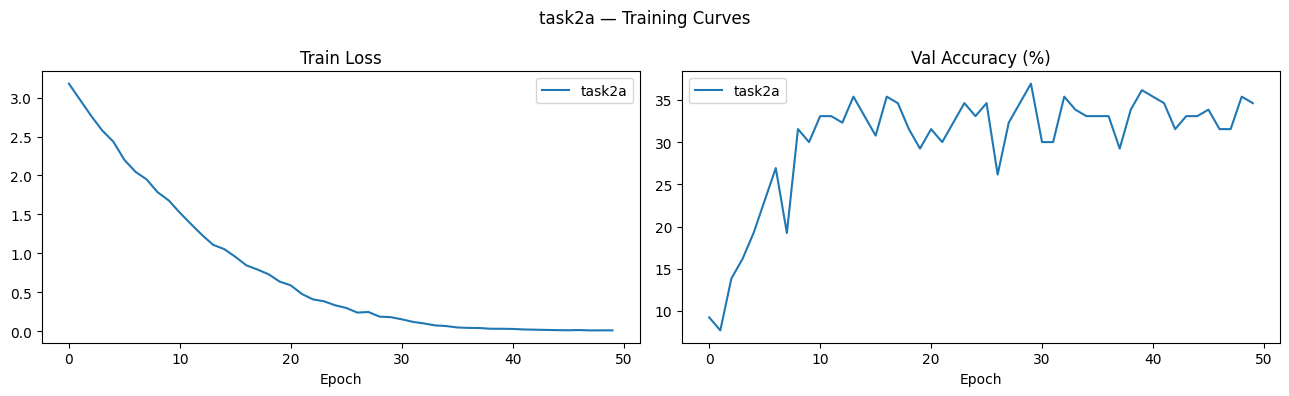

In [ ]:
plot_curves(
    {'task2a': (losses_lrelu, accs_lrelu)},
    title='task2a — Training Curves',
)

## 2b — GELU

In [ ]:
class LeNet_GELU(nn.Module):
    """Task 2b: All ReLU replaced with GELU."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.bn3   = nn.BatchNorm2d(f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.gelu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.gelu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.gelu(self.bn3(self.conv3(x))), 2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.gelu(self.fc1(x))
        x = F.gelu(self.fc2(x))
        return self.fc3(x)
        # YOUR CODE HERE
        # Replace F.relu with F.gelu
        #raise NotImplementedError


In [ ]:
START_seed()
model_gelu = LeNet_GELU()
best_acc_gelu, losses_gelu, accs_gelu = run_experiment(model_gelu, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.1806
  [Val]   Loss: 3.1329  Accuracy: 16/130 (12.31%)
  [Train] Epoch 02  Loss: 2.9340
  [Val]   Loss: 3.0349  Accuracy: 11/130 (8.46%)
  [Train] Epoch 03  Loss: 2.6548
  [Val]   Loss: 2.9953  Accuracy: 20/130 (15.38%)
  [Train] Epoch 04  Loss: 2.3981
  [Val]   Loss: 2.9267  Accuracy: 23/130 (17.69%)
  [Train] Epoch 05  Loss: 2.1786
  [Val]   Loss: 2.9799  Accuracy: 25/130 (19.23%)
  [Train] Epoch 06  Loss: 1.9354
  [Val]   Loss: 2.7045  Accuracy: 25/130 (19.23%)
  [Train] Epoch 07  Loss: 1.7542
  [Val]   Loss: 2.6374  Accuracy: 32/130 (24.62%)
  [Train] Epoch 08  Loss: 1.6308
  [Val]   Loss: 2.8737  Accuracy: 33/130 (25.38%)
  [Train] Epoch 09  Loss: 1.4562
  [Val]   Loss: 2.3919  Accuracy: 35/130 (26.92%)
  [Train] Epoch 10  Loss: 1.3393
  [Val]   Loss: 2.5918  Accuracy: 46/130 (35.38%)
  [Train] Epoch 11  Loss: 1.1686
  [Val]   Loss: 2.4172  Accuracy: 38/130 (29.23%)
  [Train] Epoch 12  Loss: 1.0326
  [Val]   Loss: 2.3401  Accuracy: 42/130 (32.31%)
  [Tr

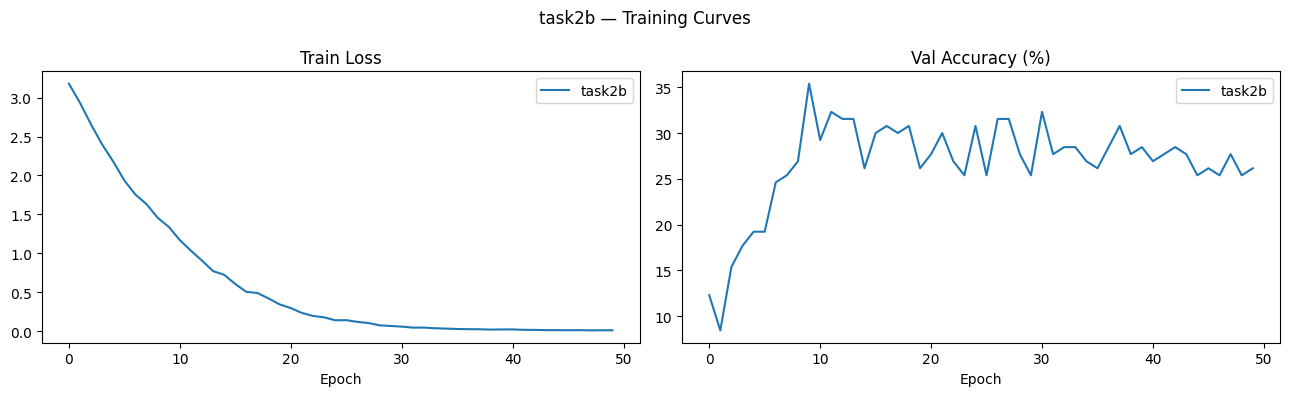

In [ ]:
plot_curves(
    {'task2b': (losses_gelu, accs_gelu)},
    title='task2b — Training Curves',
)

---
# Task 3 — Normalization Layers  *(3 points)*

The baseline uses BatchNorm. Tasks 3a and 3b start from a **BN-free** version
so you can observe the effect of each normalisation type.

`__init__` is filled in — implement `forward` only.

## Task 3 Reference — No Normalisation
Run this first to establish the no-norm baseline.

In [ ]:
class LeNetNoBN(nn.Module):
    """Task 3 reference: no normalisation of any kind."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)
        x = self.pool(x).flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [ ]:
START_seed()
model_nobn = LeNetNoBN()
best_acc_nobn, losses_nobn, accs_nobn = run_experiment(model_nobn, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.2201
  [Val]   Loss: 3.2330  Accuracy: 9/130 (6.92%)
  [Train] Epoch 02  Loss: 3.1736
  [Val]   Loss: 3.0622  Accuracy: 10/130 (7.69%)
  [Train] Epoch 03  Loss: 3.0739
  [Val]   Loss: 3.2568  Accuracy: 12/130 (9.23%)
  [Train] Epoch 04  Loss: 2.9714
  [Val]   Loss: 2.9374  Accuracy: 16/130 (12.31%)
  [Train] Epoch 05  Loss: 2.8042
  [Val]   Loss: 2.8862  Accuracy: 22/130 (16.92%)
  [Train] Epoch 06  Loss: 2.6289
  [Val]   Loss: 2.8944  Accuracy: 19/130 (14.62%)
  [Train] Epoch 07  Loss: 2.4902
  [Val]   Loss: 2.8090  Accuracy: 23/130 (17.69%)
  [Train] Epoch 08  Loss: 2.3200
  [Val]   Loss: 2.5584  Accuracy: 27/130 (20.77%)
  [Train] Epoch 09  Loss: 2.1506
  [Val]   Loss: 3.1678  Accuracy: 34/130 (26.15%)
  [Train] Epoch 10  Loss: 2.0565
  [Val]   Loss: 2.7141  Accuracy: 32/130 (24.62%)
  [Train] Epoch 11  Loss: 1.9398
  [Val]   Loss: 2.4592  Accuracy: 36/130 (27.69%)
  [Train] Epoch 12  Loss: 1.7997
  [Val]   Loss: 2.7576  Accuracy: 37/130 (28.46%)
  [Train

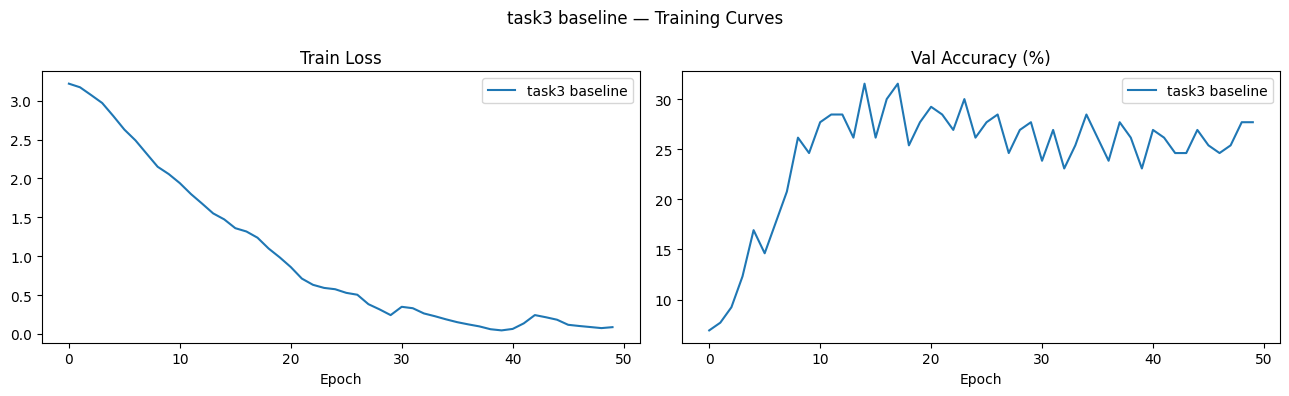

In [ ]:
plot_curves(
    {'task3 baseline': (losses_nobn, accs_nobn)},
    title='task3 baseline — Training Curves',
)

## 3a — Batch Normalization

In [ ]:
class LeNet_BN(nn.Module):
    """Task 3a: BatchNorm2d after each conv layer."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.bn3   = nn.BatchNorm2d(f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = self.pool(x).flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
        # YOUR CODE HERE
        # Pattern: conv -> bn -> relu -> maxpool (x3), then self.pool, flatten, FC
        #raise NotImplementedError


In [ ]:
# You may tune train_batch_size_bn and lr
START_seed()
train_batch_size_bn = 64
train_loader_bn = DataLoader(train_set, batch_size=train_batch_size_bn, shuffle=True, num_workers=NUM_WORKERS)
model_bn = LeNet_BN()
best_acc_bn, losses_bn, accs_bn = run_experiment(model_bn, train_loader_bn, val_loader)


  [Train] Epoch 01  Loss: 3.2008
  [Val]   Loss: 3.2095  Accuracy: 7/130 (5.38%)
  [Train] Epoch 02  Loss: 3.0450
  [Val]   Loss: 3.0898  Accuracy: 10/130 (7.69%)
  [Train] Epoch 03  Loss: 2.8682
  [Val]   Loss: 2.9752  Accuracy: 18/130 (13.85%)
  [Train] Epoch 04  Loss: 2.7099
  [Val]   Loss: 2.7857  Accuracy: 21/130 (16.15%)
  [Train] Epoch 05  Loss: 2.5632
  [Val]   Loss: 3.1855  Accuracy: 23/130 (17.69%)
  [Train] Epoch 06  Loss: 2.4102
  [Val]   Loss: 2.7865  Accuracy: 25/130 (19.23%)
  [Train] Epoch 07  Loss: 2.2916
  [Val]   Loss: 3.3635  Accuracy: 16/130 (12.31%)
  [Train] Epoch 08  Loss: 2.2109
  [Val]   Loss: 2.8921  Accuracy: 27/130 (20.77%)
  [Train] Epoch 09  Loss: 2.0324
  [Val]   Loss: 2.9313  Accuracy: 27/130 (20.77%)
  [Train] Epoch 10  Loss: 1.9158
  [Val]   Loss: 2.6573  Accuracy: 33/130 (25.38%)
  [Train] Epoch 11  Loss: 1.7947
  [Val]   Loss: 2.6560  Accuracy: 37/130 (28.46%)
  [Train] Epoch 12  Loss: 1.6701
  [Val]   Loss: 2.6383  Accuracy: 37/130 (28.46%)
  [Trai

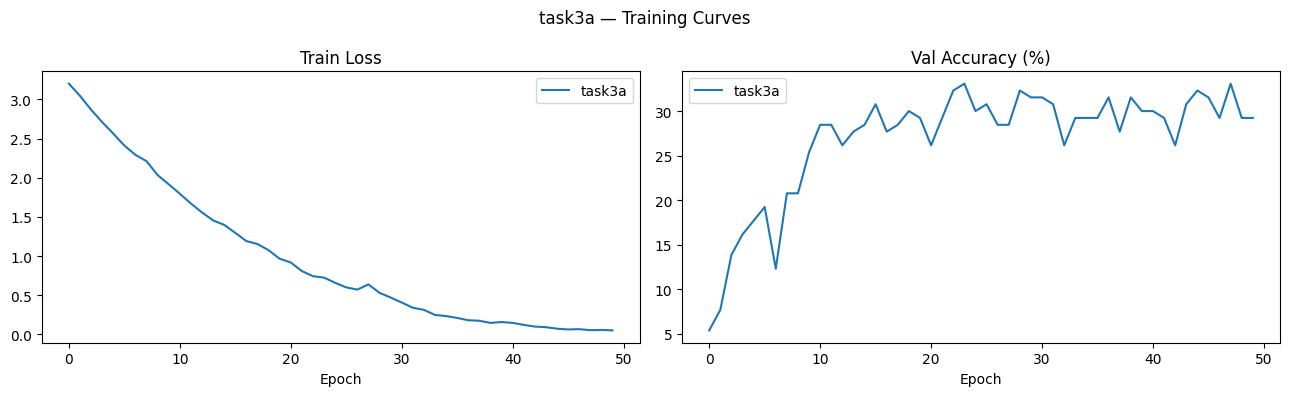

In [ ]:
plot_curves(
    {'task3a': (losses_bn, accs_bn)},
    title='task3a — Training Curves',
)

## 3b — Group Normalization
Use `nn.GroupNorm(num_groups, num_channels)`. Choose `num_groups` and justify in your report.
> Hint: `num_channels` must be divisible by `num_groups`.

In [ ]:
class LeNet_GN(nn.Module):
    """Task 3b: GroupNorm after each conv layer."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128, num_groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3)
        self.gn1   = nn.GroupNorm(num_groups, f1)
        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3)
        self.gn2   = nn.GroupNorm(num_groups, f2)
        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3)
        self.gn3   = nn.GroupNorm(num_groups, f3)
        self.pool  = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(f3 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 64)
        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.gn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.gn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.gn3(self.conv3(x))), 2)
        x = self.pool(x).flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
        # YOUR CODE HERE
        # Pattern: conv -> gn -> relu -> maxpool (x3), then self.pool, flatten, FC
        #raise NotImplementedError


In [ ]:
START_seed()
model_gn = LeNet_GN()
best_acc_gn, losses_gn, accs_gn = run_experiment(model_gn, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.2325
  [Val]   Loss: 3.2090  Accuracy: 5/130 (3.85%)
  [Train] Epoch 02  Loss: 3.1824
  [Val]   Loss: 3.2207  Accuracy: 6/130 (4.62%)
  [Train] Epoch 03  Loss: 3.1007
  [Val]   Loss: 3.0382  Accuracy: 7/130 (5.38%)
  [Train] Epoch 04  Loss: 2.9733
  [Val]   Loss: 2.9031  Accuracy: 13/130 (10.00%)
  [Train] Epoch 05  Loss: 2.8357
  [Val]   Loss: 2.8545  Accuracy: 16/130 (12.31%)
  [Train] Epoch 06  Loss: 2.7120
  [Val]   Loss: 2.8033  Accuracy: 21/130 (16.15%)
  [Train] Epoch 07  Loss: 2.5987
  [Val]   Loss: 2.7107  Accuracy: 21/130 (16.15%)
  [Train] Epoch 08  Loss: 2.4238
  [Val]   Loss: 2.4778  Accuracy: 29/130 (22.31%)
  [Train] Epoch 09  Loss: 2.2739
  [Val]   Loss: 2.6243  Accuracy: 35/130 (26.92%)
  [Train] Epoch 10  Loss: 2.1575
  [Val]   Loss: 2.3685  Accuracy: 33/130 (25.38%)
  [Train] Epoch 11  Loss: 2.0735
  [Val]   Loss: 2.4730  Accuracy: 36/130 (27.69%)
  [Train] Epoch 12  Loss: 1.9381
  [Val]   Loss: 2.4202  Accuracy: 41/130 (31.54%)
  [Train] 

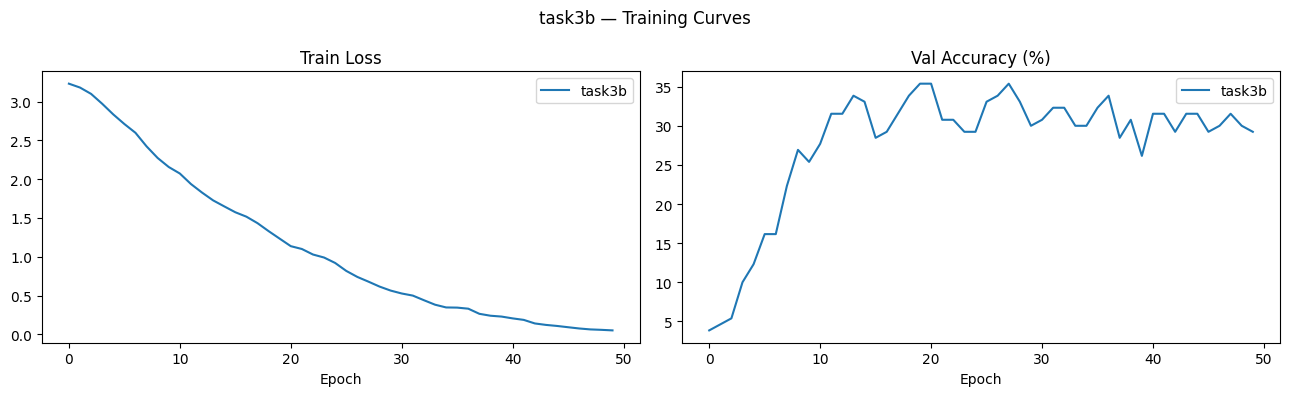

In [ ]:
plot_curves(
    {'task3b': (losses_gn, accs_gn)},
    title='task3b — Training Curves',
)

---
# Task 4 — Depthwise Separable Convolutions  *(2 points)*

Replace every `Conv2d+BN` block with a **depthwise separable convolution**.
`__init__` is filled in for both classes — implement `forward` in each.

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise separable convolution block:
        Depthwise Conv2d (groups=in_channels) -> BN -> ReLU
        Pointwise Conv2d (1x1)               -> BN -> ReLU
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size,
                                   padding=padding, groups=in_channels, bias=False)
        self.bn_dw     = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn_pw     = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn_dw(self.depthwise(x)))
        x = F.relu(self.bn_pw(self.pointwise(x)))
        return x
        # YOUR CODE HERE
        # depthwise -> bn_dw -> relu, then pointwise -> bn_pw -> relu
        #raise NotImplementedError


class LeNet_DWS(nn.Module):
    """Task 4: All Conv2d+BN blocks replaced with DepthwiseSeparableConv."""
    def __init__(self, num_classes=NUM_CLASSES, f1=32, f2=64, f3=128):
        super().__init__()
        self.block1 = DepthwiseSeparableConv(3,  f1)
        self.block2 = DepthwiseSeparableConv(f1, f2)
        self.block3 = DepthwiseSeparableConv(f2, f3)
        self.pool   = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1    = nn.Linear(f3 * 4 * 4, 128)
        self.fc2    = nn.Linear(128, 64)
        self.fc3    = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.max_pool2d(self.block1(x), 2)
        x = F.max_pool2d(self.block2(x), 2)
        x = F.max_pool2d(self.block3(x), 2)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
        # YOUR CODE HERE
        # block1 -> maxpool(2), block2 -> maxpool(2), block3 -> maxpool(2)
        # then self.pool, flatten, FC layers
        #raise NotImplementedError


In [ ]:
START_seed()
model_dws = LeNet_DWS()
best_acc_dws, losses_dws, accs_dws = run_experiment(model_dws, train_loader, val_loader)


  [Train] Epoch 01  Loss: 3.2483
  [Val]   Loss: 3.2227  Accuracy: 6/130 (4.62%)
  [Train] Epoch 02  Loss: 3.1940
  [Val]   Loss: 3.2230  Accuracy: 5/130 (3.85%)
  [Train] Epoch 03  Loss: 3.1234
  [Val]   Loss: 3.2342  Accuracy: 9/130 (6.92%)
  [Train] Epoch 04  Loss: 3.0469
  [Val]   Loss: 3.1923  Accuracy: 10/130 (7.69%)
  [Train] Epoch 05  Loss: 2.9411
  [Val]   Loss: 3.0665  Accuracy: 10/130 (7.69%)
  [Train] Epoch 06  Loss: 2.8508
  [Val]   Loss: 3.1173  Accuracy: 14/130 (10.77%)
  [Train] Epoch 07  Loss: 2.7528
  [Val]   Loss: 2.9441  Accuracy: 19/130 (14.62%)
  [Train] Epoch 08  Loss: 2.6333
  [Val]   Loss: 2.9909  Accuracy: 19/130 (14.62%)
  [Train] Epoch 09  Loss: 2.5157
  [Val]   Loss: 2.8216  Accuracy: 27/130 (20.77%)
  [Train] Epoch 10  Loss: 2.4516
  [Val]   Loss: 2.8432  Accuracy: 23/130 (17.69%)
  [Train] Epoch 11  Loss: 2.3495
  [Val]   Loss: 2.7244  Accuracy: 25/130 (19.23%)
  [Train] Epoch 12  Loss: 2.2387
  [Val]   Loss: 2.5315  Accuracy: 26/130 (20.00%)
  [Train] Ep

Baseline inference time / batch : 23.3 ms
DWS      inference time / batch : 23.5 ms
Baseline parameters : 365,849
DWS      parameters : 284,026


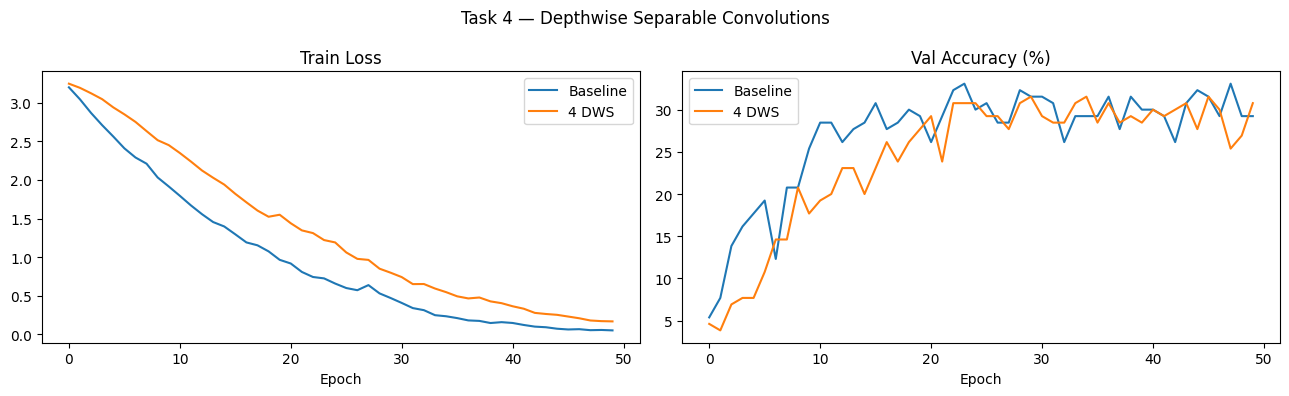

In [ ]:
def measure_inference_time(model, loader, device, n_batches=20):
    model.eval().to(device)
    t0 = time.time()
    with torch.no_grad():
        for i, (data, _) in enumerate(loader):
            if i >= n_batches: break
            model(data.to(device))
    return (time.time() - t0) / n_batches

t_base = measure_inference_time(LeNetBase(), val_loader, device)
t_dws  = measure_inference_time(model_dws,   val_loader, device)
print(f'Baseline inference time / batch : {t_base*1000:.1f} ms')
print(f'DWS      inference time / batch : {t_dws *1000:.1f} ms')
print(f'Baseline parameters : {count_parameters(LeNetBase()):,}')
print(f'DWS      parameters : {count_parameters(model_dws):,}')
plot_curves({'Baseline':(losses_baseline,accs_baseline),'4 DWS':(losses_dws,accs_dws)},
            title='Task 4 — Depthwise Separable Convolutions')

---
# Task 5 — Best Architecture  *(5 points)*

Design the best network you can within the following **hard constraints**:

| Constraint | Limit |
|---|---|
| Max parameters | **500,000** |
| Max epochs | **50** |
| Allowed layers | Lecture-covered only |
| Pre-trained weights | ❌ Not allowed |

Submit a `task5/` folder containing **`model.py`** (your `YourNet` class) and **`best_model.pth`** (saved weights).

## 5.1 — Augmentation Pipeline

In [14]:
from collections import Counter
import numpy as np
from PIL import Image
DATA_ROOT = './data'
dataset = CUB25Dataset(root=DATA_ROOT, split='train')

widths = []
heights = []

for path, label in dataset.samples:
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

print("Number of images:", len(widths))

print("\nWidth statistics")
print("Min:", widths.min())
print("Max:", widths.max())
print("Mean:", widths.mean())
print("Median:", np.median(widths))

print("\nHeight statistics")
print("Min:", heights.min())
print("Max:", heights.max())
print("Mean:", heights.mean())
print("Median:", np.median(heights))

Number of images: 567

Width statistics
Min: 121
Max: 500
Mean: 456.23104056437387
Median: 500.0

Height statistics
Min: 131
Max: 500
Mean: 385.75485008818345
Median: 375.0


In [15]:
START_seed()
class PadTo500:
    def __call__(self, img):
        w, h = img.size

        max_size = 500
        scale = max_size

        # create new square canvas
        new_img = Image.new("RGB", (scale, scale), (0, 0, 0))

        # center placement
        x = (scale - w) // 2
        y = (scale - h) // 2

        new_img.paste(img, (x, y))
        return new_img



t5_train_transform = transforms.Compose([
    PadTo500(),
    # transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])



t5_val_transform = transforms.Compose([
    PadTo500(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

t5_batch_size   = 64
t5_train_set    = CUB25Dataset(DATA_ROOT, split='train', transform=t5_train_transform)
t5_val_set      = CUB25Dataset(DATA_ROOT, split='val',   transform=t5_val_transform)
t5_train_loader = DataLoader(t5_train_set, batch_size=t5_batch_size, shuffle=True,  num_workers=NUM_WORKERS)
t5_val_loader   = DataLoader(t5_val_set,   batch_size=t5_batch_size, shuffle=False, num_workers=NUM_WORKERS)
print(f'Task-5 train: {len(t5_train_set)} | val: {len(t5_val_set)}')


Task-5 train: 567 | val: 130


## 5.2 — Your Network

In [16]:

class YourNet(nn.Module):

    def __init__(self, num_classes=21, f1=32, f2=64, f3=128, f4=128, f5=144):
        super().__init__()

        self.lrelu = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(f1)

        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(f2)

        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(f3)

        self.conv4 = nn.Conv2d(f3, f4, kernel_size=3, padding=1, bias=False)
        self.bn4   = nn.BatchNorm2d(f4)

        self.conv5 = nn.Conv2d(f4, f5, kernel_size=3, padding=1, bias=False)
        self.bn5   = nn.BatchNorm2d(f5)

        self.pool  = nn.AdaptiveAvgPool2d((2, 2))

        self.fc1   = nn.Linear(f5 * 2 * 2, 128)
        self.drop1 = nn.Dropout(0.15)

        self.fc2   = nn.Linear(128, 64)
        self.drop2 = nn.Dropout(0.15)

        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        # ── Backbone: 5 Stages of Deep Feature Extraction ──
        x = self.maxpool(self.lrelu(self.bn1(self.conv1(x))))  # 128x128 -> 64x64
        x = self.maxpool(self.lrelu(self.bn2(self.conv2(x))))  # 64x64   -> 32x32
        x = self.maxpool(self.lrelu(self.bn3(self.conv3(x))))  # 32x32   -> 16x16
        x = self.maxpool(self.lrelu(self.bn4(self.conv4(x))))  # 16x16   -> 8x8
        x = self.maxpool(self.lrelu(self.bn5(self.conv5(x))))  # 8x8     -> 4x4

        # ── Feature Flattening ──
        x = self.pool(x)                                       # Condenses to 2x2
        x = x.view(x.size(0), -1)                              # Flatten to [B, 576]

        # ── Regularized Classifier Head ──
        x = self.drop1(self.lrelu(self.fc1(x)))
        x = self.drop2(self.lrelu(self.fc2(x)))

        return self.fc3(x)
START_seed()
your_model = YourNet(num_classes=NUM_CLASSES)
n_params = count_parameters(your_model)
print(your_model)
print(f'\nParameters: {n_params:,}')
assert n_params <= MAX_PARAMS, f'❌ {n_params:,} params — exceeds {MAX_PARAMS:,} limit!'
print(f'✅ Within the {MAX_PARAMS:,} parameter budget.')


YourNet(
  (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 144, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn5): BatchNorm2d(144, eps=1e-05, mom

## 5.3 — Training

In [17]:
import os; os.makedirs('task5', exist_ok=True)

START_seed()
your_model = YourNet(num_classes=NUM_CLASSES)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(your_model.parameters(), lr=1e-3)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

your_model.to(device)
train_losses_t5, val_accs_t5 = [], []
best_acc_t5, best_epoch_t5   = 0.0, 0

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(your_model, device, t5_train_loader, optimizer, criterion, epoch)
    acc  = evaluate(your_model, device, t5_val_loader, criterion)
    train_losses_t5.append(loss); val_accs_t5.append(acc)
    if acc > best_acc_t5:
        best_acc_t5, best_epoch_t5 = acc, epoch
        torch.save(your_model.state_dict(), 'task5/best_model.pth')
    # scheduler.step()

print(f'\n✅ Best val: {best_acc_t5:.2f}% at epoch {best_epoch_t5}')
print(f'   Time: {time.time()-t0:.1f}s | Params: {count_parameters(your_model):,}')


  [Train] Epoch 01  Loss: 3.2196
  [Val]   Loss: 3.2134  Accuracy: 2/130 (1.54%)
  [Train] Epoch 02  Loss: 3.1400
  [Val]   Loss: 3.1570  Accuracy: 11/130 (8.46%)
  [Train] Epoch 03  Loss: 3.0670
  [Val]   Loss: 2.9900  Accuracy: 11/130 (8.46%)
  [Train] Epoch 04  Loss: 2.9727
  [Val]   Loss: 2.8528  Accuracy: 14/130 (10.77%)
  [Train] Epoch 05  Loss: 2.8797
  [Val]   Loss: 3.1790  Accuracy: 19/130 (14.62%)
  [Train] Epoch 06  Loss: 2.8761
  [Val]   Loss: 2.7429  Accuracy: 19/130 (14.62%)
  [Train] Epoch 07  Loss: 2.7682
  [Val]   Loss: 3.0260  Accuracy: 13/130 (10.00%)
  [Train] Epoch 08  Loss: 2.7312
  [Val]   Loss: 2.6701  Accuracy: 14/130 (10.77%)
  [Train] Epoch 09  Loss: 2.6434
  [Val]   Loss: 2.8419  Accuracy: 28/130 (21.54%)
  [Train] Epoch 10  Loss: 2.5773
  [Val]   Loss: 2.5874  Accuracy: 24/130 (18.46%)
  [Train] Epoch 11  Loss: 2.5786
  [Val]   Loss: 2.6815  Accuracy: 32/130 (24.62%)
  [Train] Epoch 12  Loss: 2.5112
  [Val]   Loss: 2.6019  Accuracy: 28/130 (21.54%)
  [Train

## 5.4 — Export model.py
Copy your `YourNet` class (and any helper classes) into `task5/model.py`.
It must be importable as `from model import YourNet` without any other files.

In [21]:
template = '''
import torch
import torch.nn as nn
import torch.nn.functional as F

# paste any helper classes here


class YourNet(nn.Module):
    def __init__(self, num_classes=21, f1=32, f2=64, f3=128, f4=128, f5=144):
        super().__init__()
        self.lrelu = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(3,  f1, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(f1)

        self.conv2 = nn.Conv2d(f1, f2, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(f2)

        self.conv3 = nn.Conv2d(f2, f3, kernel_size=3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(f3)

        self.conv4 = nn.Conv2d(f3, f4, kernel_size=3, padding=1, bias=False)
        self.bn4   = nn.BatchNorm2d(f4)

        self.conv5 = nn.Conv2d(f4, f5, kernel_size=3, padding=1, bias=False)
        self.bn5   = nn.BatchNorm2d(f5)

        self.pool  = nn.AdaptiveAvgPool2d((2, 2))

        self.fc1   = nn.Linear(f5 * 2 * 2, 128)
        self.drop1 = nn.Dropout(0.15)

        self.fc2   = nn.Linear(128, 64)
        self.drop2 = nn.Dropout(0.15)

        self.fc3   = nn.Linear(64, num_classes)

    def forward(self, x):
        # YOUR FORWARD
        x = self.maxpool(self.lrelu(self.bn1(self.conv1(x))))  # 128x128 -> 64x64
        x = self.maxpool(self.lrelu(self.bn2(self.conv2(x))))  # 64x64   -> 32x32
        x = self.maxpool(self.lrelu(self.bn3(self.conv3(x))))  # 32x32   -> 16x16
        x = self.maxpool(self.lrelu(self.bn4(self.conv4(x))))  # 16x16   -> 8x8
        x = self.maxpool(self.lrelu(self.bn5(self.conv5(x))))  # 8x8     -> 4x4

        # ── Feature Flattening ──
        x = self.pool(x)                                       # Condenses to 2x2
        x = x.view(x.size(0), -1)                              # Flatten to [B, 576]

        # ── Regularized Classifier Head ──
        x = self.drop1(self.lrelu(self.fc1(x)))
        x = self.drop2(self.lrelu(self.fc2(x)))

        return self.fc3(x)
'''

os.makedirs('task5', exist_ok=True)
with open('task5/model.py', 'w') as f:
    f.write(template.strip() + '\n')
print('Template written to task5/model.py — fill it in with your implementation.')


Template written to task5/model.py — fill it in with your implementation.
